# 01 EDA

A text classification project that classifies resumes in different categories- HR, Data Science, Web Developer, etc. based on the content. **Multi-class** classification- 25 Job Categories

We use TF-IDF + classic-ML Pipeline

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
%matplotlib inline
import Utility

In [2]:
df= Utility.load_data()
df.rename(columns={'Category' : 'label', 'Resume': 'text'})
print('rows:', len(df), '| classes:', df['label'].nunique())
df.head()

rows: 962 | classes: 25


,label,text
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \nMay 2013 to May 2017 B.E ...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \n MCA YMCAUST, Faridabad..."


## 1. Class Distribution

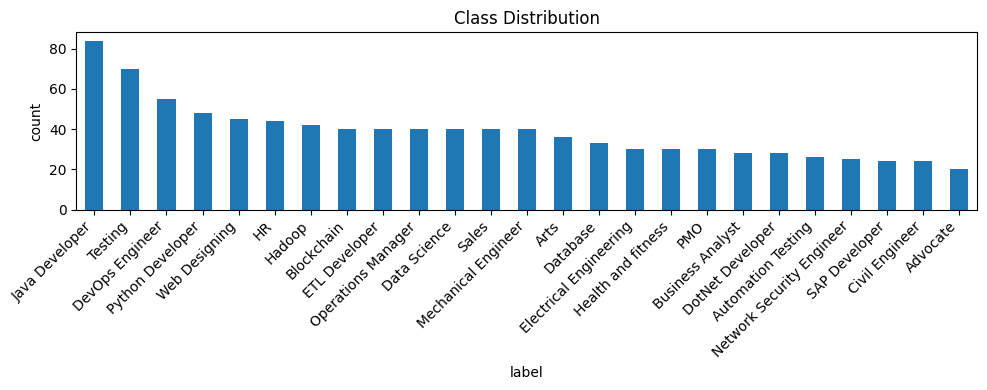

label
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Blockchain                   40
ETL Developer                40
Operations Manager           40
Data Science                 40
Sales                        40
Mechanical Engineer          40
Arts                         36
Database                     33
Electrical Engineering       30
Health and fitness           30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Civil Engineer               24
Advocate                     20


In [3]:
fig, ax= plt.subplots(figsize=(10, 4))
vc= df['label'].value_counts()
vc.plot(kind='bar', ax=ax); 
ax.set_title('Class Distribution'); ax.set_ylabel('count')
plt.xticks(rotation= 45, ha='right'); 
plt.tight_layout(); plt.show()
print(vc.to_string())


## 2. Text Length Distribution

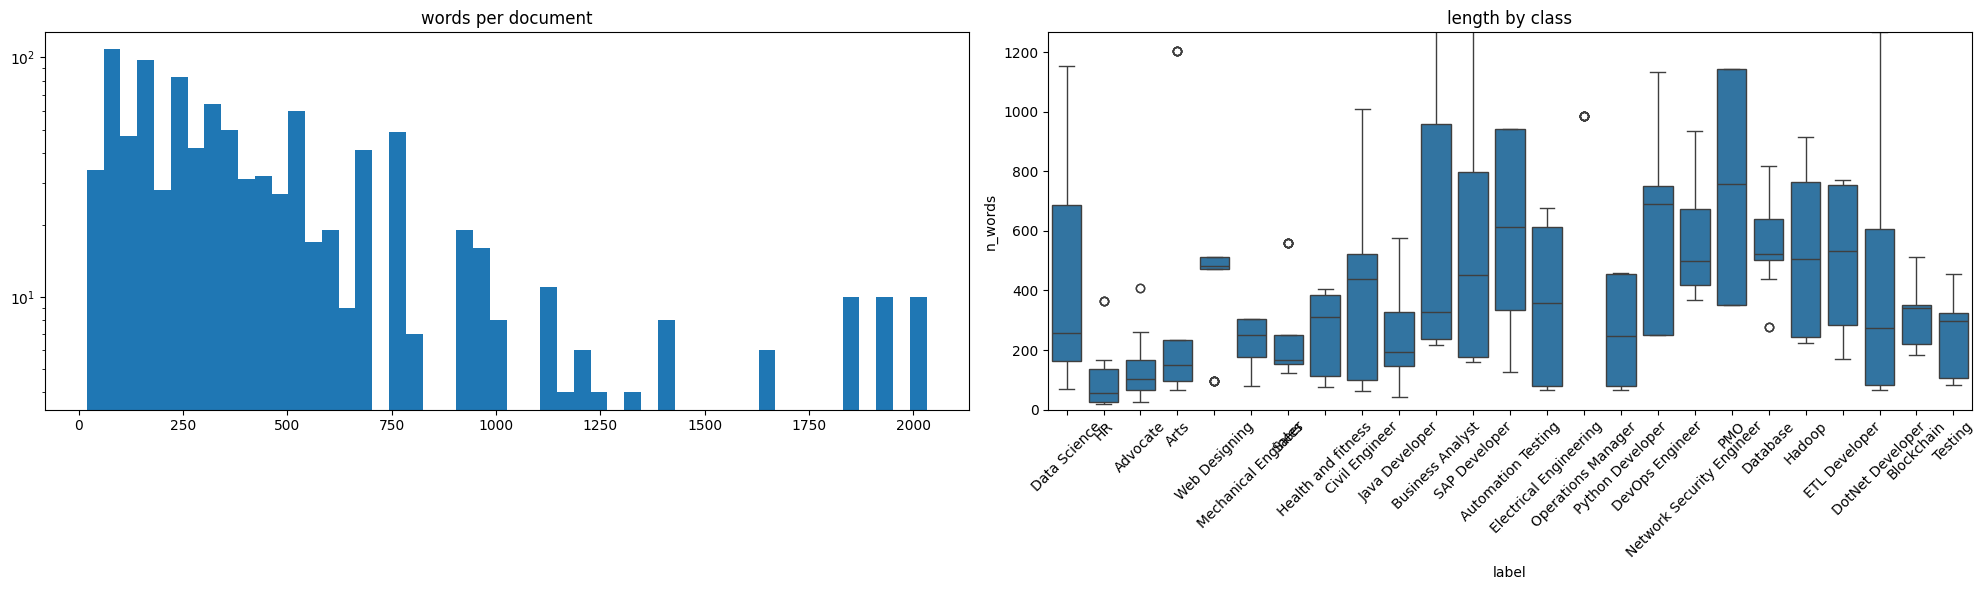

words per doc- median 329, max 2209


In [10]:
df['n_words']= df['text'].astype(str).str.split().apply(len)
fig, ax= plt.subplots(1,2, figsize= (20, 6))
ax[0].hist(df['n_words'].clip(upper=df['n_words'].quantile(0.99)), bins=50); 
ax[0].set_title('words per document');
ax[0].set_yscale('log')
sns.boxplot(x= 'label', y= 'n_words', data=df, ax=ax[1]); 
ax[1].set_ylim(0, df['n_words'].quantile(0.95)); 
ax[1].set_title('length by class'); 
ax[1].tick_params(axis= 'x', rotation= 45)
plt.tight_layout();
plt.show()
print('words per doc- median %d, max %d'%(df['n_words'].median(), df['n_words'].max()))

## 3. Most Frequent words (raw)

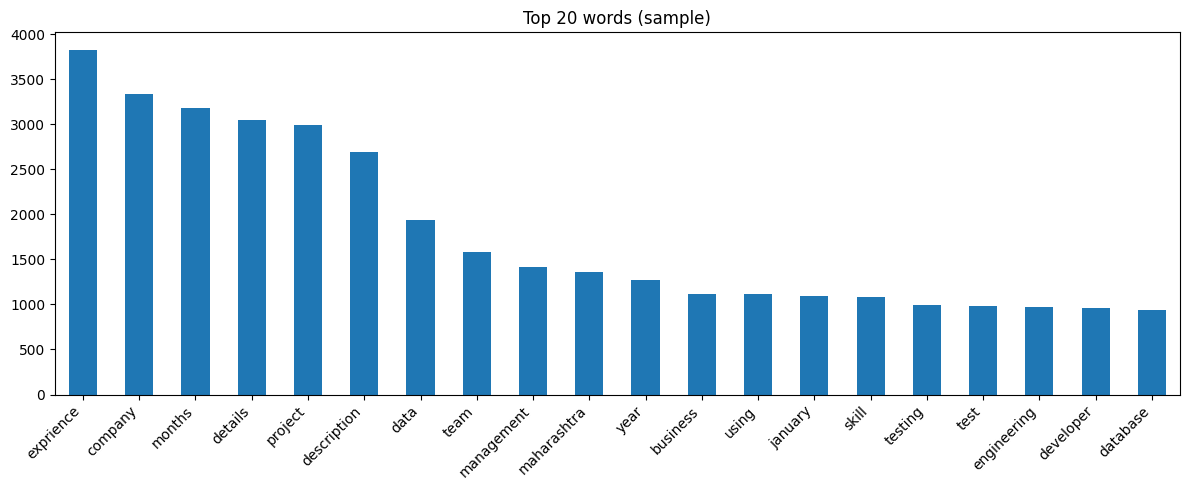

In [11]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
words= Counter()
for t in df['text'].astype(str).head(3000):
    words.update(w for w in t.lower().split() if w.isalpha() and w not in ENGLISH_STOP_WORDS and len(w)>2)
top= pd.Series(dict(words.most_common(20)))
fig,ax= plt.subplots(figsize=(12, 5)); 
top.plot(kind='bar', ax=ax); 
ax.set_title('Top 20 words (sample)'); 
plt.xticks(rotation= 45, ha= 'right'); 
plt.tight_layout(); 
plt.show()

## 4. Sample Documents per Class